# 📊 Customer Retention & Churn Analysis using Python

## 🚀 Project Workflow

This project covers:

1. Data Loading
2. Data Cleaning using Pandas
3. Exploratory Data Analysis (EDA)
4. Univariate Analysis
5. Bivariate Analysis
6. Advanced Visualizations using Seaborn
7. Business Insights

---

## 💡 Example Insights

* Customers with month-to-month contracts churn more.
* Higher monthly charges increase churn probability.
* Customers with longer tenure are more loyal.
* Electronic check users show higher churn.
* Fiber optic users have relatively higher churn.

---

## 📌 Final Recommendations

* Offer discounts for long-term contracts.
* Reduce churn in electronic check customers.
* Improve service quality for fiber optic users.
* Create loyalty programs for new customers.
* Target high-risk churn customers with retention campaigns.



## Importing Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In [40]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [41]:
# Display first 5 rows
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [42]:
print(df.info())
print(df.describe())
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Data Cleaning

In [43]:
# check missing value
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [44]:
# check duplicate
print(df.duplicated().sum())

0


In [47]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [48]:
# Convert 0 and 1 into labels
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0:'No', 1:'Yes'})

## Churn Distribution

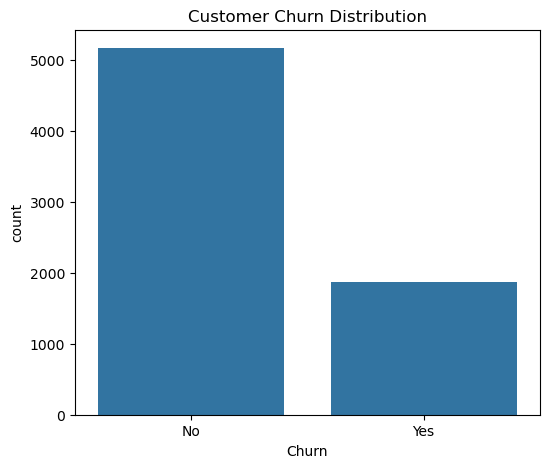

In [49]:
plt.figure(figsize=(6,5))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.show()

## Univariate Analysis

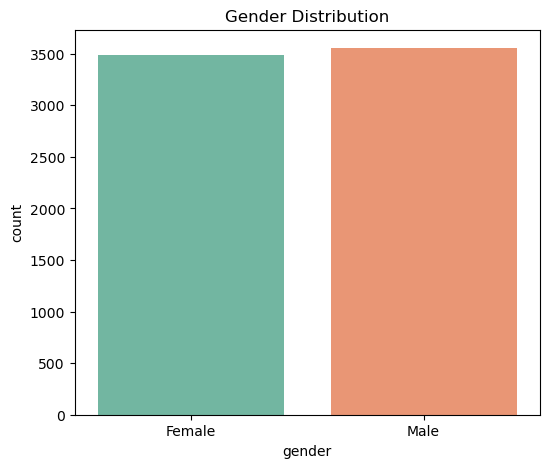

In [50]:
# gender distribution
plt.figure(figsize=(6,5))

sns.countplot(x='gender', data=df, palette='Set2')

plt.title('Gender Distribution')
plt.show()

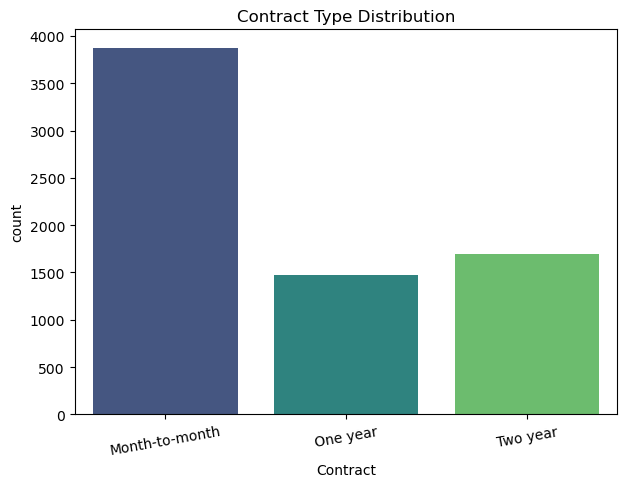

In [51]:
# Contract Type Distribution
plt.figure(figsize=(7,5))

sns.countplot(x='Contract', data=df, palette='viridis')

plt.title('Contract Type Distribution')
plt.xticks(rotation=10)
plt.show()

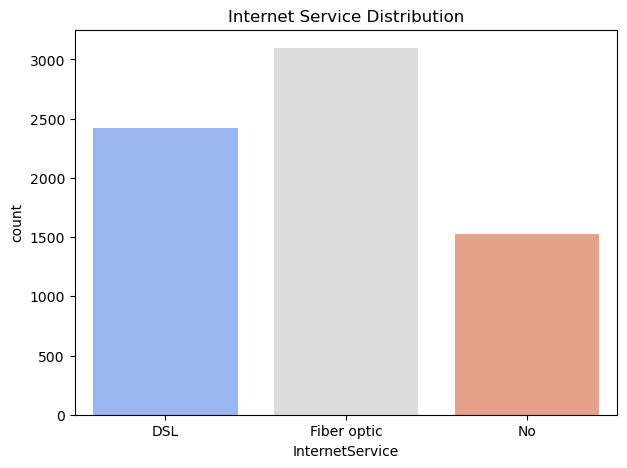

In [52]:
# Internet Service Distribution
plt.figure(figsize=(7,5))

sns.countplot(x='InternetService', data=df, palette='coolwarm')

plt.title('Internet Service Distribution')
plt.show()

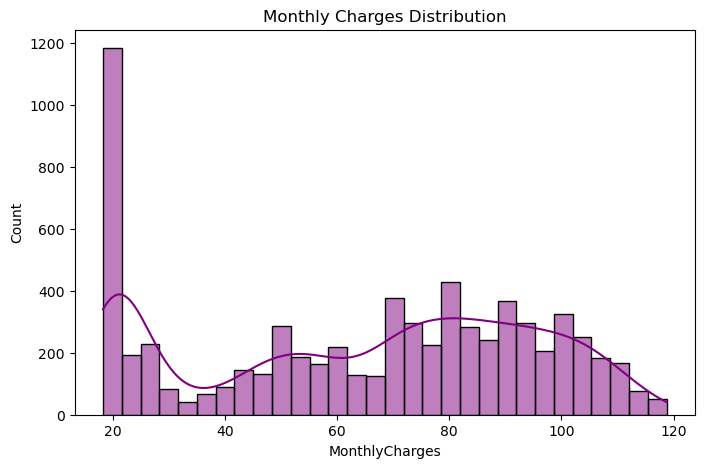

In [53]:
# Monthly Charges Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], kde=True, bins=30, color='purple')

plt.title('Monthly Charges Distribution')
plt.show()

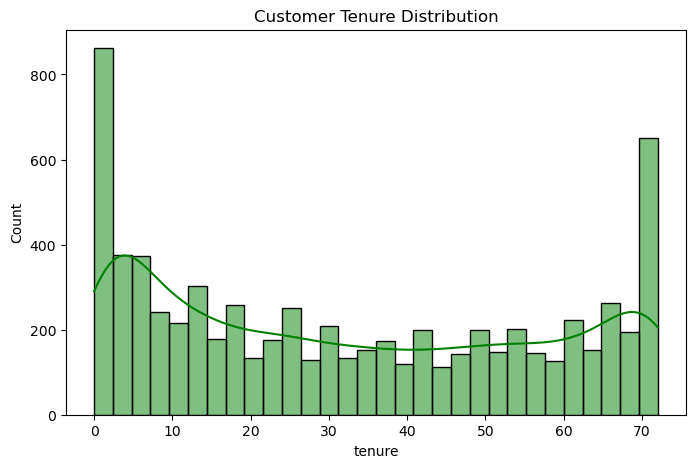

In [54]:
# Tenure Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], kde=True, bins=30, color='green')

plt.title('Customer Tenure Distribution')
plt.show()

## Bivariate Analysis

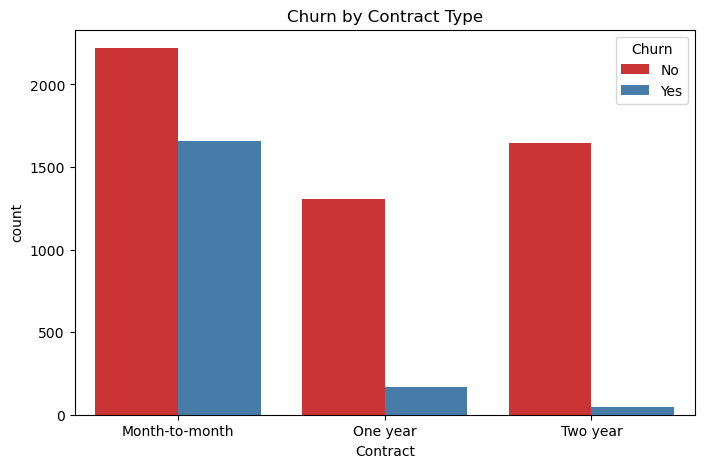

In [55]:
# Churn vs Contract
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df, palette='Set1')

plt.title('Churn by Contract Type')
plt.show()

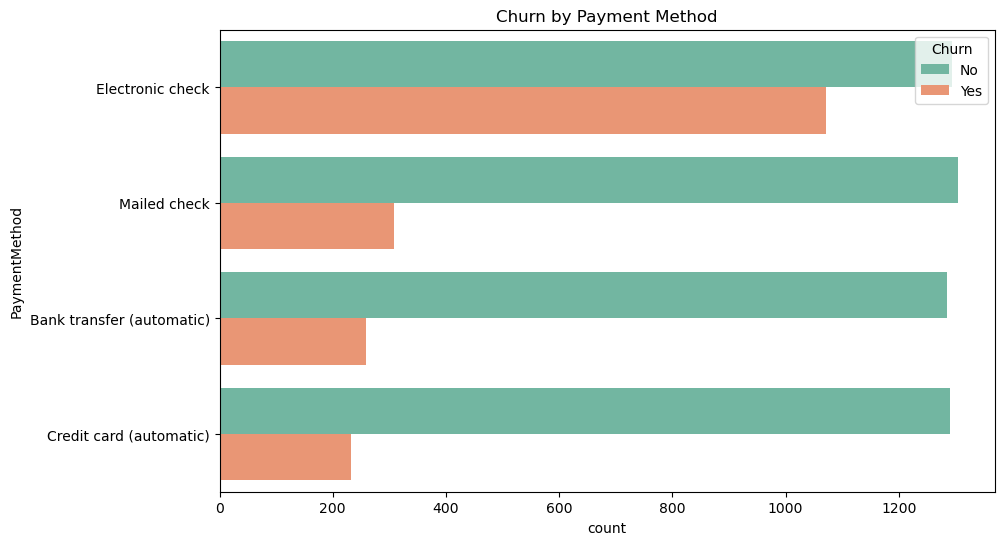

In [56]:
# Churn vs Payment Method
plt.figure(figsize=(10,6))

sns.countplot(y='PaymentMethod', hue='Churn', data=df, palette='Set2')

plt.title('Churn by Payment Method')
plt.show()

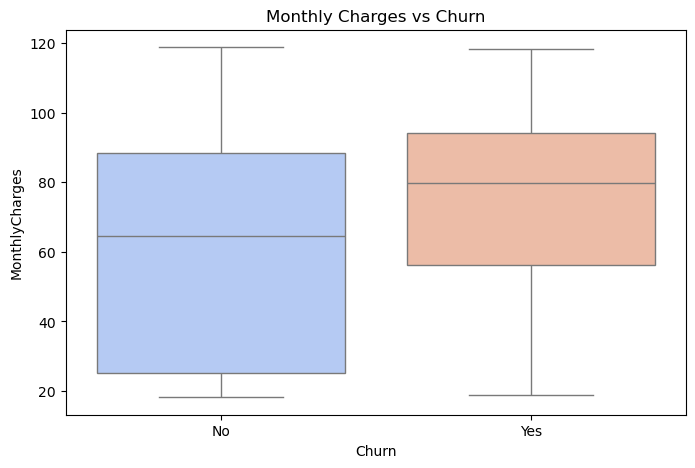

In [57]:
# Monthly Charges vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette='coolwarm')

plt.title('Monthly Charges vs Churn')
plt.show()

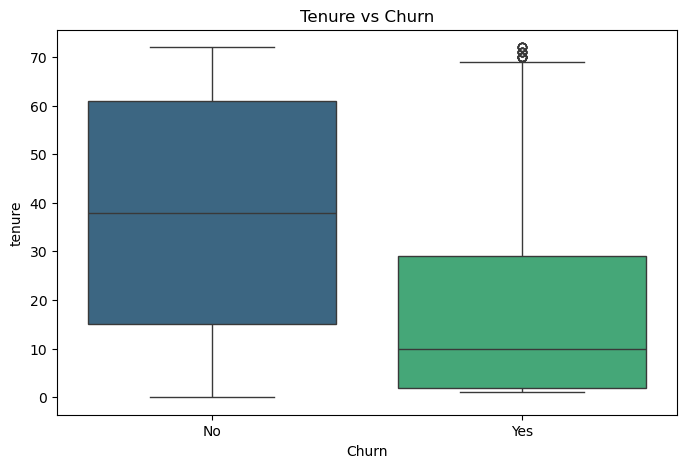

In [58]:
# Tenure vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df, palette='viridis')

plt.title('Tenure vs Churn')
plt.show()

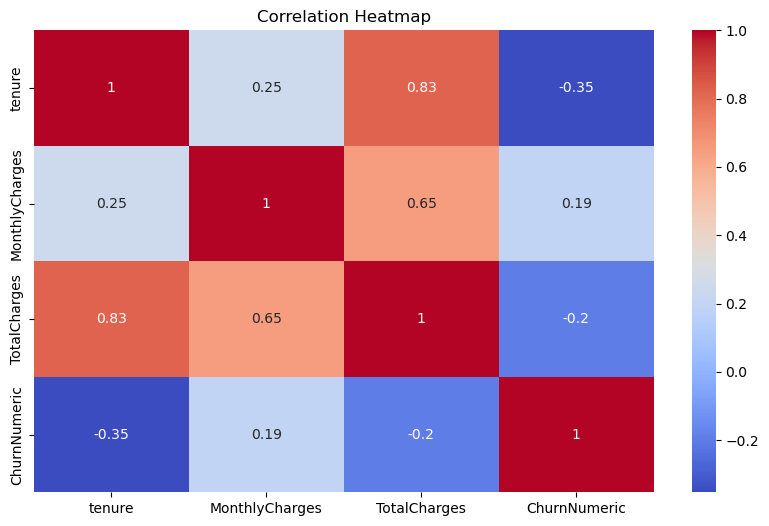

In [59]:
# Coorelation map

df['ChurnNumeric'] = df['Churn'].map({'Yes':1, 'No':0})

# Select numeric columns

numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

## Advanced Visualization

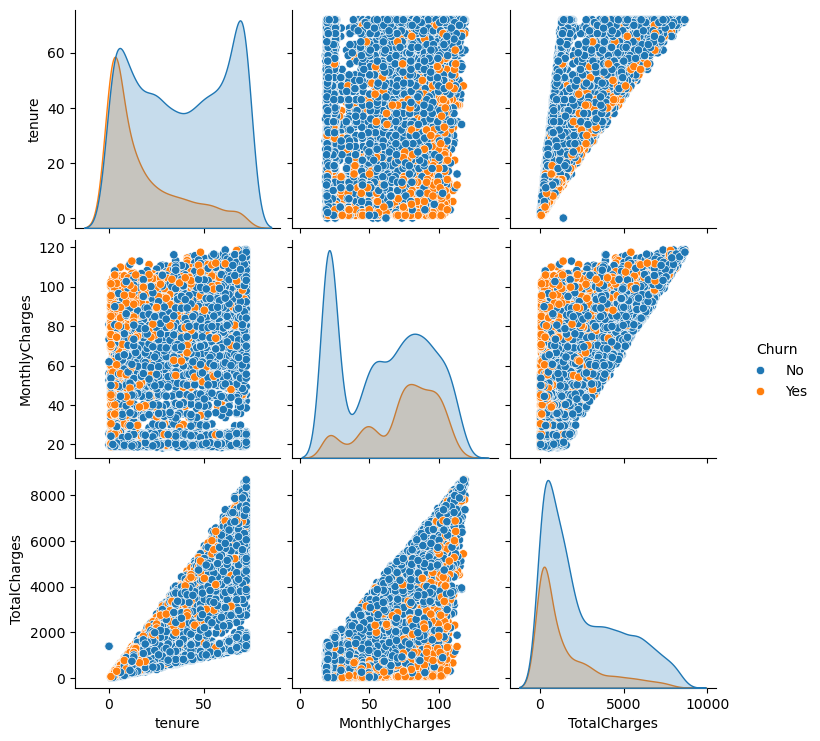

In [60]:
# pair plot 
sample_df = df[['tenure','MonthlyCharges','TotalCharges','Churn']]

sns.pairplot(sample_df, hue='Churn')

plt.show()

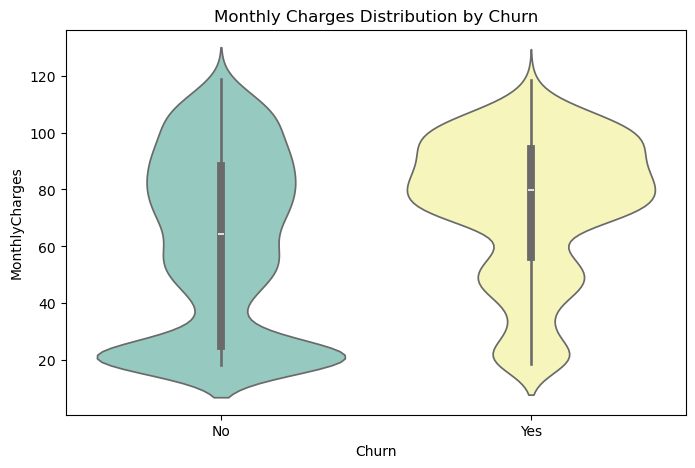

In [61]:
# violin plot
plt.figure(figsize=(8,5))

sns.violinplot(x='Churn', y='MonthlyCharges', data=df, palette='Set3')

plt.title('Monthly Charges Distribution by Churn')
plt.show()

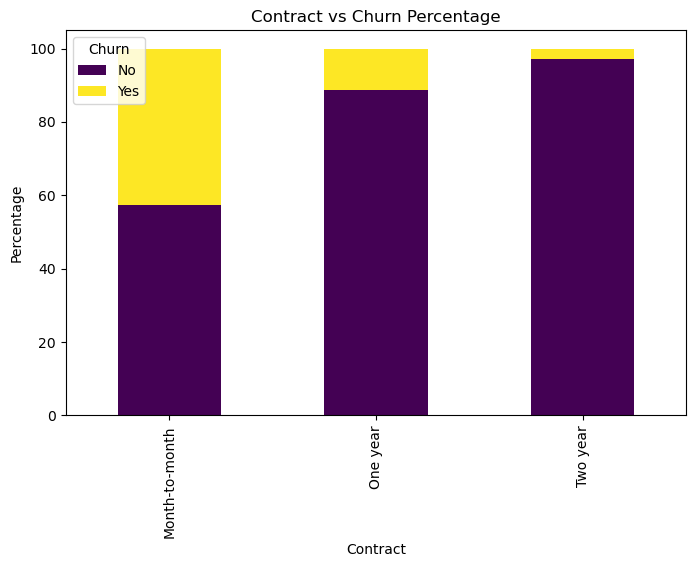

In [62]:
# Stacked Percentage Chart
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

contract_churn.plot(kind='bar', stacked=True, figsize=(8,5), colormap='viridis')

plt.title('Contract vs Churn Percentage')
plt.ylabel('Percentage')
plt.show()

## Business Insights

In [64]:
# Churn Rate
churn_rate = (df['Churn'].value_counts(normalize=True) * 100)
print(churn_rate)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
